## README
Upon opening this colab, please upload the attached `still_shake.csv` to the `sample_data` folder before running the code below.

In [ ]:
# necessary imports
import matplotlib.pyplot as plt
import pandas as pd
import math

The microbit is shaken at these times: 
[4, 5, 6, 7, 8, 9, 10, 11, 16, 17, 18, 19, 20]


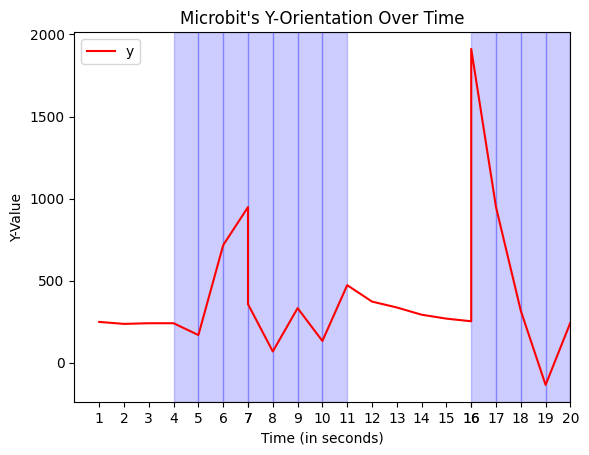

In [ ]:
points = []
# formatting data
with open('/content/sample_data/still_shake.csv') as file:
  points = pd.read_csv(file, usecols=['Time (seconds)', 'y'], dtype={'Time (seconds)':float,'y':float})

  # leveling out the time markers
  points['Time (seconds)'] = points['Time (seconds)'].apply(lambda x: math.floor(x))

# plotting out on the graph
points.plot(x='Time (seconds)',y='y', kind='line', color='r')

# series for all y-values, to be compared to one another
yvals = points['y']

# array for shaking times
shaking = []

one_more = False

# comparing the y-values and highlighting where shaking is happening
for x in range(0,21):
  # if difference in y-orientation is great enough...
  if(math.fabs(yvals[x+1]-yvals[x]) > 150):
    # highlight the area with the difference
    plt.axvspan(x+1,x,color='b',alpha=0.2)
    shaking.append(x)
    one_more = True

  elif(one_more):
    shaking.append(x)
    one_more = False

# plot values
plt.title("Microbit's Y-Orientation Over Time")
plt.xlabel("Time (in seconds)")
plt.ylabel("Y-Value")
plt.xticks(points['Time (seconds)'])
plt.xlim(0,20)
print("The microbit is shaken at these times: \n" + str(shaking))


### Classification Accuracy:
Expected movement $m_{expected} = 0.5$, or 50% of elapsed time (10 seconds)

Actual detected movement $m_{actual} = 0.55$, or 55% of elapsed time (11 seconds)

Error $m_{error}=(m_{actual}-m_{expected}) / m_{actual} = .091$, or 9.1% error.

### Suggestions for Code Improvement:
- Rather than a rule-based classifier, implementing a proper training model could help make this code more versatile for future accelerometer tests.
- This code only uses the Δy when detecting whether the micro-bit is shaking or not; in the future, the code should be altered to account for the Δx as well.